# Day 3 — Species distribution modeling

---

Summary: we have records of where species have been observed, but those points are not yet an explanation. Where is the species found? Where is it absent, or simply not recorded? What environmental conditions might explain the pattern? Once we have an idea of what determines the presence, absence, or even abundance of a species, we can go beyond observation, and model the species’ distribution. With such models, we can predict where we have no data, identify key regions for conservation, and even model what could happen if the environment were to change.

- PART I: From observations to ecological questions.
- PART II: Identifying environmental predictors: climate, land use, and habitat suitability.
- PART III: Species distribution modeling.

In [1]:
# 1
import os
if not os.path.exists("/content/USLS-Workshop"):
    !git clone "https://github.com/Cas-Dec/USLS-Workshop.git" /content/USLS-Workshop
%cd /content/USLS-Workshop
!pip install -q .

%cd /content/USLS-Workshop/notebooks

Cloning into '/content/USLS-Workshop'...
remote: Enumerating objects: 517, done.
remote: Counting objects: 100% (219/219), done.
remote: Compressing objects: 100% (136/136), done.
remote: Total 517 (delta 126), reused 156 (delta 71), pack-reused 298 (from 2)
Receiving objects: 100% (517/517), 93.71 MiB | 23.57 MiB/s, done.
Resolving deltas: 100% (255/255), done.
Updating files: 100% (83/83), done.
/content/USLS-Workshop
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
/content/USLS-Workshop/notebooks


In [2]:
# 2
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# *PART I: From observations to ecological questions*

### The Philippine tarsier (Carlito syrichta)

Look at this cute lil' bugger:

<img src="https://github.com/Cas-Dec/USLS-Workshop/blob/main/notebooks/images/Philippine_tarsier.jpg?raw=1" alt="Philippine tarsier" style="width:60%">

The Philippine tarsier is one of the smallest primates in the world, weighing barely 100–160 grams, with enormous eyes adapted for its nocturnal, insect-hunting lifestyle. It is endemic to the Philippines, found mainly in the southeastern islands — Bohol, Samar, and Leyte — where it lives in dense forest understory and secondary growth. The species is currently classified as **Near Threatened** on the IUCN Red List, primarily due to ongoing habitat loss from deforestation and agricultural conversion, along with pressure from the pet trade and unregulated tourism. Because tarsiers are shy, territorial, and highly sensitive to habitat disruption, they are often considered a strong indicator species for forest health in the regions they inhabit.

*Sources: [Philippine tarsier — Wikipedia](https://en.wikipedia.org/wiki/Philippine_tarsier); [Carlito syrichta — IUCN Red List](https://www.iucnredlist.org/species/21492/17977226)*

### The Question

**Imagine the Philippine government is about to sign off a contract with a massive agricultural firm**, allowing many thousands of hectares of **natural land on Mindanao** to be converted to large monoculture plantations of oil palm, Cavendish banana, and pineapple. As a biologist, your heart bleeds, because you know this is **a death sentence for many thousands of species** currently inhabiting the land. The loss of habitat diversity and vertical structures, insect depletion with pesticide applications, and habitat fragmentation means very little species will actually be able to live in these monocultures.

**However, there's one last chance.** The government has implemented a strict nature conservation protocol to safeguard the Phillipine tarsier, and **you have been contracted for advise on natural area protection.** If somehow you could prove how important Mindanao nature is for the Philippine tarsier, you might just convince them to cancel this horrible deal. But how will you do this? Do you have strong evidence for that? Just some internet sources won't do, the government will need a strong report to change their minds. Launching an observation campaign to look for tarsier throughout this massive area takes a lot of time, is resource intensive and very expensive—it's not an option.

> **Discussion:** How would you go about that? Based on what knowledge or evidence would you identify key natural regions to protect? Could you make a convincing, evidence-based argument?

Let's see if we can put our newly developed programming skills to use. At this point, you've already worked with a lot of climatic and environmental data that might very well be relevant for how suitable a given habitat is for the Philippine tarsier. Also, just so happens, you've already worked with the same GBIF data that also includes tarsier sightings. Let's check it out.

### Load and filter occurrence records

In the `gbif_mammals_philippines.csv` compilation (all present-day terrestrial mammal records for the Philippines),
there are also a bunch of tarsier recordings. **🖊️ Let's check them out!**

In [3]:
# 3
# --- Load gbif_mammals_philippines.csv ---
mammals = pd.read_csv("../data/processed/day2/gbif_mammals_philippines.csv")      # ✏️ the file is under ../data/processed/day2/

# ✏️ inspect the data with the head() method
mammals.head()

,gbifID,institutionCode,basisOfRecord,individualCount,establishmentMeans,year,month,day,islandGroup,island,...,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters,class,order,family,genus,datasetKey,species,iucnRedListCategory
0,2249795545,"Mined from GenBank, NCBI",MATERIAL_SAMPLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15.586542,121.822090,NaN,Mammalia,Pholidota,Manidae,Manis,040c5662-da76-4782-a48e-cdea1892d14c,Manis javanica,NaN
1,2633453444,"University of the Philippines Diliman, Institu...",MATERIAL_SAMPLE,NaN,NaN,2016.0,4.0,28.0,NaN,NaN,...,17.047280,122.387190,NaN,Mammalia,Chiroptera,Pteropodidae,Haplonycteris,040c5662-da76-4782-a48e-cdea1892d14c,Haplonycteris fischeri,NaN
2,5862486417,"Mined from GenBank, NCBI",MATERIAL_SAMPLE,NaN,NaN,2008.0,7.0,29.0,NaN,NaN,...,14.654000,121.067000,NaN,Mammalia,Chiroptera,Vespertilionidae,Scotophilus,040c5662-da76-4782-a48e-cdea1892d14c,Scotophilus kuhlii,LC
3,2633176707,"Mined from GenBank, NCBI",MATERIAL_SAMPLE,NaN,NaN,2009.0,3.0,16.0,NaN,NaN,...,13.983361,121.916664,NaN,Mammalia,Chiroptera,Pteropodidae,Rousettus,040c5662-da76-4782-a48e-cdea1892d14c,Rousettus amplexicaudatus,NaN
4,2633368454,Field Museum of Natural History,MATERIAL_SAMPLE,NaN,NaN,2017.0,1.0,11.0,NaN,NaN,...,12.242680,121.127960,NaN,Mammalia,Chiroptera,Pteropodidae,Rousettus,040c5662-da76-4782-a48e-cdea1892d14c,Rousettus amplexicaudatus,NaN


> **Discussion:** What column in the data shows the observed **species**? How can we select only the Philippine tarsier from the data?

**💡 Example:** one of the columns in the data is `genus`. To illustrate extracting something of interest, here's how you can select occurences of e.g. the genus *Manis*:

In [12]:
# 4
manis_example = mammals[mammals["genus"] == "Carlito syrichta"]

In [13]:
# 5
# --- Extract Tarsier Records ---
tarsier = mammals[mammals["species"] == "Carlito syrichta"]  # ✏️ look at the example above!
print(f'Raw records: {len(tarsier)}')
tarsier.head()

Raw records: 408


,gbifID,institutionCode,basisOfRecord,individualCount,establishmentMeans,year,month,day,islandGroup,island,...,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters,class,order,family,genus,datasetKey,species,iucnRedListCategory
325,1141846838,KU,PRESERVED_SPECIMEN,NaN,NaN,2010.0,1.0,19.0,NaN,NaN,...,10.35000,125.61700,NaN,Mammalia,Primates,Tarsiidae,Carlito,1d04e739-98a9-4e16-9970-8f8f3bf9e9e3,Carlito syrichta,NT
537,1141846793,KU,PRESERVED_SPECIMEN,NaN,NaN,2009.0,7.0,2.0,NaN,NaN,...,9.52500,125.07980,NaN,Mammalia,Primates,Tarsiidae,Carlito,1d04e739-98a9-4e16-9970-8f8f3bf9e9e3,Carlito syrichta,NT
648,686493660,KU,PRESERVED_SPECIMEN,NaN,NaN,2007.0,10.0,8.0,NaN,NaN,...,11.81310,125.27770,NaN,Mammalia,Primates,Tarsiidae,Carlito,1d04e739-98a9-4e16-9970-8f8f3bf9e9e3,Carlito syrichta,NT
679,686493162,KU,PRESERVED_SPECIMEN,NaN,NaN,2008.0,5.0,2.0,NaN,NaN,...,8.40218,125.87930,NaN,Mammalia,Primates,Tarsiidae,Carlito,1d04e739-98a9-4e16-9970-8f8f3bf9e9e3,Carlito syrichta,NT
962,1305201532,KU,PRESERVED_SPECIMEN,NaN,NaN,2016.0,4.0,3.0,NaN,NaN,...,11.20745,125.36723,NaN,Mammalia,Primates,Tarsiidae,Carlito,1d04e739-98a9-4e16-9970-8f8f3bf9e9e3,Carlito syrichta,NT


If you don't immediately remember, this is how it works:

```python
mammals["genus"] == "Manis"
```

Creates a binary of `True` / `False` for each row: True where the genus is Manis, and False where it is not. If you then index mammals with this, **you select only those rows where the binary is True**.

**🖊️ Your turn:** extract the Philippine tarsier occurences from the `mammals` DataFrame you created. Hint: there's a column called `species`, and the tarsiers' scientific name is `Carlito syrichta`.

### Where has the Philippine tarsier been spotted?

**🖊️ Plot** your `tarsier` data over a Philippines outline. Does the species look randomly scattered, or clustered?

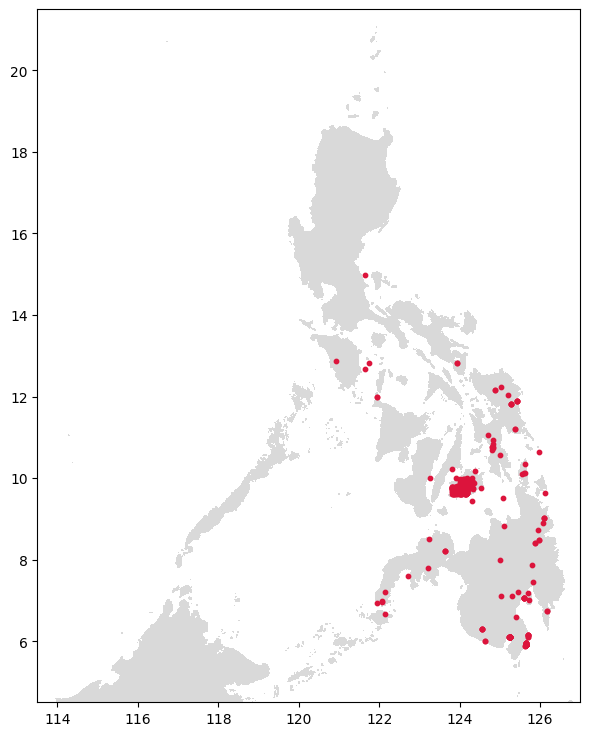

In [14]:
# 6
fig, ax = plt.subplots(figsize=(7, 9))      # ✏️ create a 7 inch wide and 9 inch tall figure with an axis for plotting

# below adds the land-sea mask to the plot
lsm = xr.open_dataset("../data/processed/land-sea-mask_0p00833333.nc")  # ✏️ open land-sea-mask_0p00833333.nc, path: ../data/processed/

land = lsm['land_sea_mask'].values > 0.5
LSM_LAT, LSM_LON = lsm['lat'].values, lsm['lon'].values
ax.contourf(LSM_LON, LSM_LAT, land, levels=[0.5, 1], colors=['#d9d9d9'])

# ✏️ use the scatter() method to plot the tarsier records
ax.scatter(tarsier["decimalLongitude"], tarsier["decimalLatitude"], s=10, color='crimson')      # Hint: scatter the decimalLongitude and decimalLatitude values from the tarsier DataFrame

> **Discussion :** What do you see, are there **any** remarkable **patterns?** Do the sightings match **where you expected** the tarsier to be found?

According to [Wikipedia](https://en.wikipedia.org/wiki/Philippine_tarsier):

```text
The Philippine tarsier (Carlito syrichta) is a species of tarsier endemic to the Philippines. It is found in the southeastern part of the archipelago, particularly on the islands of Bohol, Samar and Leyte. It is a member of the approximately 45-million-year-old family Tarsiidae, whose name is derived from its elongated "tarsus" or ankle bone. Formerly a member of the genus Tarsius, it has since been listed as the only member of the genus Carlito, a new genus named after the conservationist Carlito Pizarras.

Its geographic range also includes Maripipi Island, Siargao Island, Basilan Island and Dinagat Island. Tarsiers have also been reported in Sarangani, although they may be different subspecies.
```

**In blue is the tarsier geographic distribution according to Wikipedia:**

<img src="https://github.com/Cas-Dec/USLS-Workshop/blob/main/notebooks/images/tarsier_geodistrib.png?raw=1" alt="Tarsier Geodistribution" style="width:20%">

**Two things should jump out looking at our data:**
- A dense cluster on Bohol
- A handful of points far outside the species' known native range: one in Luzon, a few around Mindoro/Romblon.

> **Discussion:** Why is there a dense cluster on Bohol? Why could it be that we also see points outside the species' native range? Are these real ecological signal?

Let's clean up the data a bit, in the hope that we get something more representative of actual natural tarsier occurrences. We can do two intuitive things: **exclude geographic regions, and remove duplicate observations** at identical locations (e.g. in a zoo).

Here's a region we could reasonably exclude:

Text(124.7, 15.5, 'lon = 124.2°E')

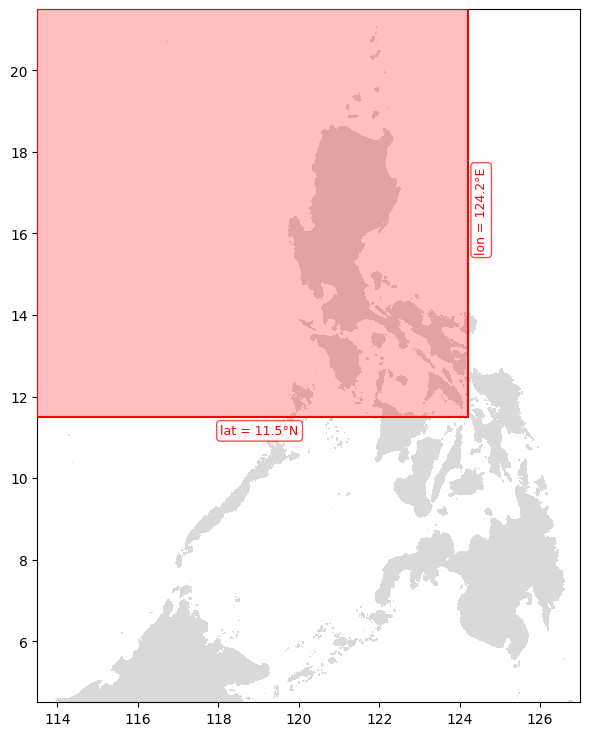

In [15]:
# 7
fig, ax = plt.subplots(figsize=(7, 9))

# land-sea contour
ax.contourf(LSM_LON, LSM_LAT, land, levels=[0.5, 1], colors=['#d9d9d9'])

# exclusion box: longitudes <= 124.1, latitudes >= 11.5
# plot the box as a rectangle
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

excl_lon_max = 124.2
excl_lat_min = 11.5
rect_fill = Rectangle((xmin, excl_lat_min), excl_lon_max - xmin, ymax - excl_lat_min,
                      facecolor='red', alpha=0.25, edgecolor='none', zorder=3)
rect_edge = Rectangle((xmin, excl_lat_min), excl_lon_max - xmin, ymax - excl_lat_min,
                      facecolor='none', edgecolor='red', linewidth=1.5, zorder=4)
ax.add_patch(rect_fill)
ax.add_patch(rect_edge)

# horizontal label for the latitude cutoff (11.5°N)
ax.text(
    120, excl_lat_min - 0.5,          # slightly left of right edge, just above the line
    f'lat = {excl_lat_min}°N',
    ha='right', va='bottom',
    fontsize=9, color='red',
    bbox=dict(facecolor='white', edgecolor='red', alpha=0.7, boxstyle='round,pad=0.3'),
    zorder=5
)

# vertical label for the longitude cutoff (124.1°E)
ax.text(
    excl_lon_max + 0.5, 15.5,          # slightly left of the line, near bottom
    f'lon = {excl_lon_max}°E',
    ha='right', va='bottom',
    rotation=90,
    fontsize=9, color='red',
    bbox=dict(facecolor='white', edgecolor='red', alpha=0.7, boxstyle='round,pad=0.3'),
    zorder=5
)

So, in words, any observation at latitudes above 11.5°N **AND** longitudes below 124.2°E should be excluded. You know what that sounds like by now, that's right, a **binary** `True` / `False` filtering step.

We want to filter for **two requirements at the same time**, something you haven't done before. Here's an example of how you could do that for some other columns in your `tarsier` DataFrame: only observations before 2010 and of the first half of the year (January-July).

In [16]:
# 8
double_filter = (tarsier["year"] < 2010) & (tarsier["month"] <= 6)
double_filter

,0
325,False
537,False
648,False
679,True
962,False
...,...
48552,False
48555,False
48569,False
48581,False


Easy! So if we want to select only those sightings, we can easily index

```python
tarsier[double_filter]
```

Or, and this will be **important for the next exercise**, you can also select the opposite: where the filter is `False`, by using the `NOT` sign `~`:

In [17]:
# 9
~double_filter  # 💡 by placing the '~' before the binary, we get the opposite!

,0
325,True
537,True
648,True
679,False
962,True
...,...
48552,True
48555,True
48569,True
48581,True


If we use this to index `tarsier`, we will get all observations since 2010 **OR** that were registered in the second half of each year:

In [18]:
# 10
tarsier[~double_filter]

,gbifID,institutionCode,basisOfRecord,individualCount,establishmentMeans,year,month,day,islandGroup,island,...,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters,class,order,family,genus,datasetKey,species,iucnRedListCategory
325,1141846838,KU,PRESERVED_SPECIMEN,NaN,NaN,2010.0,1.0,19.0,NaN,NaN,...,10.350000,125.617000,NaN,Mammalia,Primates,Tarsiidae,Carlito,1d04e739-98a9-4e16-9970-8f8f3bf9e9e3,Carlito syrichta,NT
537,1141846793,KU,PRESERVED_SPECIMEN,NaN,NaN,2009.0,7.0,2.0,NaN,NaN,...,9.525000,125.079800,NaN,Mammalia,Primates,Tarsiidae,Carlito,1d04e739-98a9-4e16-9970-8f8f3bf9e9e3,Carlito syrichta,NT
648,686493660,KU,PRESERVED_SPECIMEN,NaN,NaN,2007.0,10.0,8.0,NaN,NaN,...,11.813100,125.277700,NaN,Mammalia,Primates,Tarsiidae,Carlito,1d04e739-98a9-4e16-9970-8f8f3bf9e9e3,Carlito syrichta,NT
962,1305201532,KU,PRESERVED_SPECIMEN,NaN,NaN,2016.0,4.0,3.0,NaN,NaN,...,11.207450,125.367230,NaN,Mammalia,Primates,Tarsiidae,Carlito,1d04e739-98a9-4e16-9970-8f8f3bf9e9e3,Carlito syrichta,NT
991,686493661,KU,PRESERVED_SPECIMEN,NaN,NaN,2007.0,10.0,15.0,NaN,NaN,...,11.820000,125.270000,NaN,Mammalia,Primates,Tarsiidae,Carlito,1d04e739-98a9-4e16-9970-8f8f3bf9e9e3,Carlito syrichta,NT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48552,2840611115,NaN,HUMAN_OBSERVATION,1.0,NaN,2017.0,10.0,29.0,NaN,NaN,...,9.691212,123.952548,25.0,Mammalia,Primates,Tarsiidae,Carlito,8a863029-f435-446a-821e-275f4f641165,Carlito syrichta,NaN
48555,4881593373,NaN,HUMAN_OBSERVATION,5.0,NaN,2024.0,1.0,24.0,NaN,NaN,...,9.676008,124.091100,NaN,Mammalia,Primates,Tarsiidae,Carlito,8a863029-f435-446a-821e-275f4f641165,Carlito syrichta,NaN
48569,2835659714,NaN,HUMAN_OBSERVATION,4.0,NaN,2013.0,1.0,21.0,NaN,NaN,...,9.694000,123.954000,1000.0,Mammalia,Primates,Tarsiidae,Carlito,8a863029-f435-446a-821e-275f4f641165,Carlito syrichta,NaN
48581,2836311292,NaN,HUMAN_OBSERVATION,1.0,NaN,2017.0,10.0,29.0,NaN,NaN,...,9.691122,123.952757,25.0,Mammalia,Primates,Tarsiidae,Carlito,8a863029-f435-446a-821e-275f4f641165,Carlito syrichta,NaN


**🖊️ Your turn:** filter the `tarsier` record so that anything at `decimalLatitude >= 11.5` **AND** `decimalLongitude <= 124.2` gets excluded.

In [24]:
# 11
out_of_range = (tarsier["decimalLatitude"] >= 11.5) & (tarsier["decimalLongitude"] <= 124.2)  # ✏️ make the double filter

print(f'Dropping {int(out_of_range.sum())} likely out-of-range records')

# ✏️ use your out_of_range filter
tarsier_filtered = tarsier[~double_filter]  # Hint: we want tarsier records that are NOT (~) out of range

Dropping 8 likely out-of-range records


**🖊️ Make a quick plot** to check if you got it right:

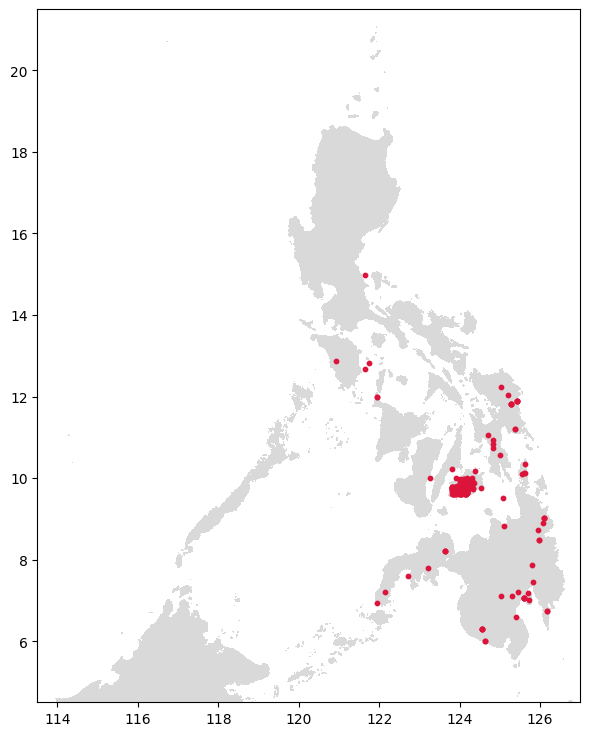

In [25]:
# 12
fig, ax = plt.subplots(figsize=(7, 9))      # ✏️ create a 7 inch wide and 9 inch tall figure with an axis for plotting

# below adds the land-sea mask to the plot
ax.contourf(LSM_LON, LSM_LAT, land, levels=[0.5, 1], colors=['#d9d9d9'])

# ✏️ use the scatter() method to plot the tarsier_filtered records
ax.scatter(tarsier_filtered["decimalLongitude"], tarsier_filtered["decimalLatitude"], s=10, color='crimson')      # Hint: scatter the decimalLongitude and decimalLatitude values from the tarsier_filtered DataFrame

Looks good? Then we can **continue to the second filtering step**: remove duplicate observations that were likely taken in e.g. zoos. We will use the **same trick as** we've already used **in day 2: rounding coordinates** a bit so the resolution gets reduced. Let's round to two decimals behind the comma, that way, sightings with less than a kilometer between them will become "duplicates" at the same location.

**🖊️ Add two new columns to** `tarsier_filtered`: one called `lon_r` for the rounded longitude, and `lat_r` for the rounded latitude, both rounded to two decimals behind the comma:

In [22]:
# 13
# Add two columns that round the lat/lon to 2 decimal places (0.01° ~ 1 km) for duplicate removal
tarsier_filtered['lon_r'] = tarsier_filtered['decimalLongitude'].round(2)       # ✏️ Hint: use .round(2) to round tarsier_filtered['decimalLongitude'] to 2 decimal places
tarsier_filtered['lat_r'] = tarsier_filtered['decimalLatitude'].round(2)        # ✏️ Hint: use .round(2) to round tarsier_filtered['decimalLatitude'] to 2 decimal places

tarsier_filtered['lat_r'].head()

/tmp/ipykernel_1397/2448155429.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tarsier_filtered['lon_r'] = tarsier_filtered['decimalLongitude'].round(2)       # ✏️ Hint: use .round(2) to round tarsier_filtered['decimalLongitude'] to 2 decimal places
/tmp/ipykernel_1397/2448155429.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tarsier_filtered['lat_r'] = tarsier_filtered['decimalLatitude'].round(2)        # ✏️ Hint: use .round(2) to round tarsier_filtered['decimalLatitude'] to 2 decimal places


,lat_r
325,10.35
537,9.52
648,11.81
962,11.21
991,11.82


And, what a surprise, there's already a nice in-built method called `drop_duplicates`. Below, we use it to drop tarsier sightings at duplicate coordinates. Also, we rename the very long decimalLongitude and -Latitude columns to lon and lat, and drop all other information from the data:

In [23]:
# 14
tarsier_clean = tarsier_filtered.drop_duplicates(subset=['lon_r', 'lat_r'])
tarsier_clean = tarsier_clean.rename(columns={'decimalLongitude': 'lon', 'decimalLatitude': 'lat'})[['lon', 'lat']]

print(f'Clean presence set: {len(tarsier_clean)} points')

tarsier_clean.head()

Clean presence set: 262 points


,lon,lat
325,125.61700,10.35000
537,125.07980,9.52500
648,125.27770,11.81310
962,125.36723,11.20745
991,125.27000,11.82000


> **Discussion:** In words, can you describe what the `tarsier_clean` data represents? What columns does it have? What do the values mean?

### Yay! We have presence data

At this point, you've successfully cleaned up the data. It now tells you at what unique, sensible locations the Philippine tarsier has been observed. Whether we can rely on the data to be truthful is very hard to assess with the limited knowledge we have of how each point was collected, but let's assume that the data quality is good.

> **Discussion:** What *can* this data tell you, **and what** can it **not**? If there is no sighting of a Philippine tarsier somewhere, can you conclude the tarsier is not present in that area? What factors unrelated to tarsier presence might influence whether they are spotted or not? *Hint:* think of who is recording these data, below is a small summary:

```text
GBIF data originates from a global network of endorsed institutions and data publishers that contribute records documenting the occurrence of species at specific places and times.  The data is aggregated from diverse sources, including natural history museum specimens, citizen science networks (such as iNaturalist), environmental recording schemes, and DNA barcodes.
```

GBIF gives us presences, not absences — an unrecorded area might be truly unsuitable, or just unsurveyed (no roads, no observers nearby). We can't tell the difference from the points alone. So at this point it is very hard to prove that a piece of nature might be worth protecting if there are no tarsier sightings available, even though you might well know the species lives there.

## *PART II: Identifying environmental predictors: climate, land use, and habitat suitability.*

### Where does the Philippine tarsier live?

We already know that the tarsier is found mainly in the southeastern islands—Bohol, Samar, and Leyte—where it lives in dense forest understory and secondary growth. But **why there specifically?**

Tarsiers are **tiny** (100–160 g), **nocturnal insectivores that rely on dense vegetation** with plenty of vines, saplings, and thick understory to vertically cling-and-leap between perches while hunting and hiding from predators such as owls and snakes—open or degraded land simply doesn't give them enough cover or perch density to move and forage safely. **Their small body size** also means a high surface-area-to-volume ratio, **making them prone to rapid heat loss and dehydration**; the closed canopy of humid lowland and lower-montane forest buffers temperature extremes and keeps humidity high, which both protects the tarsiers directly and sustains the insect populations they depend on for food. **This is why tarsiers are consistently associated with intact, humid forest** rather than open, hot, or seasonally dry terrain.

*Sources: [Philippine tarsier — Wikipedia](https://en.wikipedia.org/wiki/Philippine_tarsier); [Carlito syrichta — IUCN Red List](https://www.iucnredlist.org/species/21492/17977226); [Philippine Tarsier Foundation — About the Tarsier](https://www.tarsierfoundation.org/tarsier)*

But climate and habitat structure aren't the whole story—**why don't tarsiers live further north**, say on Luzon, even where the forest looks just as suitable? The answer is less about present-day environment and more about **geologic history**. During past ice ages, sea levels dropped enough that Bohol, Leyte, Samar, Mindanao, and a few smaller islands were fused into a single landmass ("Greater Mindanao"), while Luzon sat on its own, separately-connected landmass and was never joined to it even at the lowest historical sea levels. Tarsiers are small, forest-obligate animals that can't swim or fly any meaningful distance, so once their populations were isolated on Greater Mindanao, they had no way of reaching Luzon—regardless of whether Luzon's forests were otherwise a good climatic match.

*Sources: Heaney, L.R. (1985), "Zoogeographic evidence for middle and late Pleistocene land bridges to the Philippine Islands", Modern Quaternary Research in Southeast Asia; Esselstyn, J.A. et al. (2010), "Frontiers of biogeography: new insights from old world rats", Journal of Biogeography*

### Alright, that's cool and all, *but how can we use that information*?

In part I you created `tarsier_clean`: clean observation data showing where tarsiers have been spotted. From the above, **we know that climate, vegetation, elevation and geologic history are important**. Well, that's great, as **in the previous days you've already been working with most of this data** extensively.

| Data | Resolution | Extent | Status |
|---|---|---|---|
| Tarsier occurrences | 1 km | Philippines-wide | ✅ have — you created `tarsier_clean` |
| Köppen-Geiger classification | 1 km | Philippines-wide | ✅ have `kg_philippines_present.nc` |
| WorldClim BIO5 (max temp of warmest month) & BIO14 (precip of driest month) | ~1 km | Philippines-wide | ✅ have `worldclim_bio_philippines_1970_2000.nc` — 1970–2000 baseline, the only period WorldClim offers at this resolution |
| Elevation (Copernicus DEM GLO-30, aggregated) | 1 km | Philippines-wide | ✅ have (`dem_philippines_1km.nc`) — native 30 m block-averaged onto a 1 km grid |
| Land-sea mask | 1 km | Philippines-wide | ✅ have (`land-sea-mask_0p00833333.nc`) |
| Forest cover (Hansen) / satellite imagery | 1 km | Philippines-wide | ✅ have (`forest_cover_philippines_1km.nc`) — a 1-km version we made for you, sacrificing the original 30m resolution |

(np.float64(113.49882600013643),
 np.float64(126.99877200014271),
 np.float64(4.500341999960256),
 np.float64(21.500273999968158))

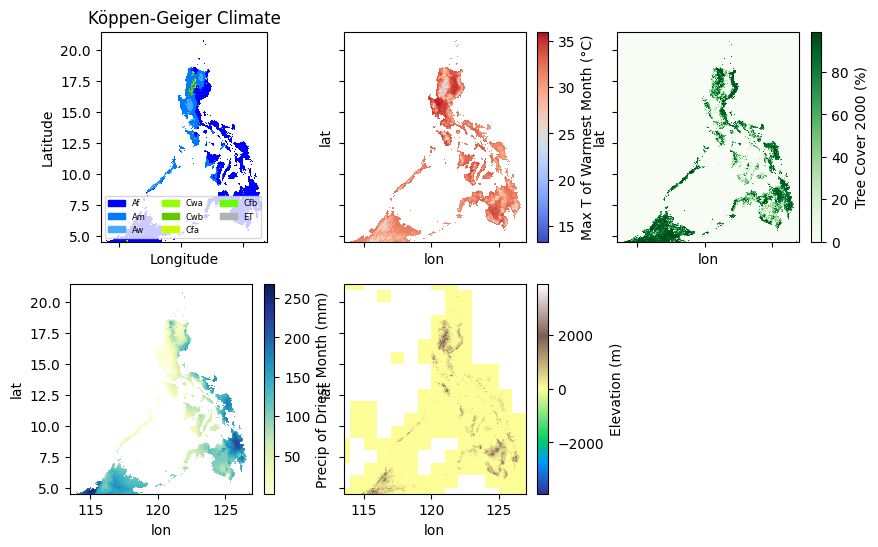

In [26]:
# 15
from workshop_utils.plotting import plot_kg_map

# ✏️ Open the datasets
kg_grid   = xr.open_dataset("../data/processed/kg_philippines_present.nc")
bio_ds    = xr.open_dataset("../data/processed/worldclim_bio_philippines_1970_2000.nc")
dem_ds    = xr.open_dataset("../data/processed/dem_philippines_1km.nc")     # 💡 "DEM" stands for "Digital Elevation Model"
forest_ds = xr.open_dataset("../data/processed/forest_cover_philippines_1km.nc")

# 2x3 subplots for the environmental variables that could predict tarsier habitat suitability
fig, axes = plt.subplots(2, 3,  # ✏️ create a 2x3 grid of subplots
                         figsize=(10, 6),
                         sharex=True, sharey=True)

# categorical, so a legend instead of a colorbar -- plot_kg_map handles the Beck et al. colour scheme for us
kg_legend = plot_kg_map(axes[0, 0], kg_grid["kg_class"].where(kg_grid["kg_class"] > 0), title="Köppen-Geiger Climate")
axes[0, 0].legend(handles=kg_legend, loc="lower left", fontsize=6, ncol=3, frameon=True)

bio_ds["bio5"].plot(ax=axes[0, 1],
                         cmap="coolwarm",
                         cbar_kwargs={"label": "Max T of Warmest Month (°C)"})
bio_ds["bio14"].plot(ax=axes[1, 0],
                         cmap="YlGnBu",
                         cbar_kwargs={"label": "Precip of Driest Month (mm)"})
dem_ds["elevation"].plot(ax=axes[1, 1],
                         cmap="terrain",
                         cbar_kwargs={"label": "Elevation (m)"})
forest_ds["treecover2000"].plot(ax=axes[0, 2],
                         cmap="Greens",
                         cbar_kwargs={"label": "Tree Cover 2000 (%)"})

# Hide the last empty subplot
axes[1, 2].axis('off')

Without a land-sea contour, some of these plots are a little hard to read as-is. By now, we've been plotting the land-sea mask really often, repeating the same code over and over. You know what that sounds like? The perfect opportunity to **make a small, reusable function**!

**🖊️ Your turn:** write a small reusable `add_lsm(ax)` helper that loads the highest-resolution land-sea mask we have (`../data/processed/land-sea-mask_0p00833333.nc`) and draws the Philippine coastline on `ax` as a single outline — a *contour*, not a filled `contourf`, so it traces the land/sea boundary without covering up the data underneath.

In [27]:
# 16
def add_lsm(ax):
    lsm = xr.open_dataset("../data/processed/land-sea-mask_0p00833333.nc")  # ✏️ File: land-sea-mask_0p00833333.nc, path: ../data/processed/
    ax.contour(
        lsm['lon'],  # ✏️ What are the x-values? lsm['lon]
        lsm['lat'],  # ✏️ y-values? lsm['lat']
        lsm['land_sea_mask'],  # ✏️ z-values? lsm['land_sea_mask']
        levels=[0.5],
        colors='black',
        linewidths=0.6
    )

If that's correct, we can easily use your new helper function to add land-sea contours to all the `axes` in the `fig` above. **🖊️ Loop over axes 1-5 and add the land see mask** using a `for`-loop and your new `add_lsm`

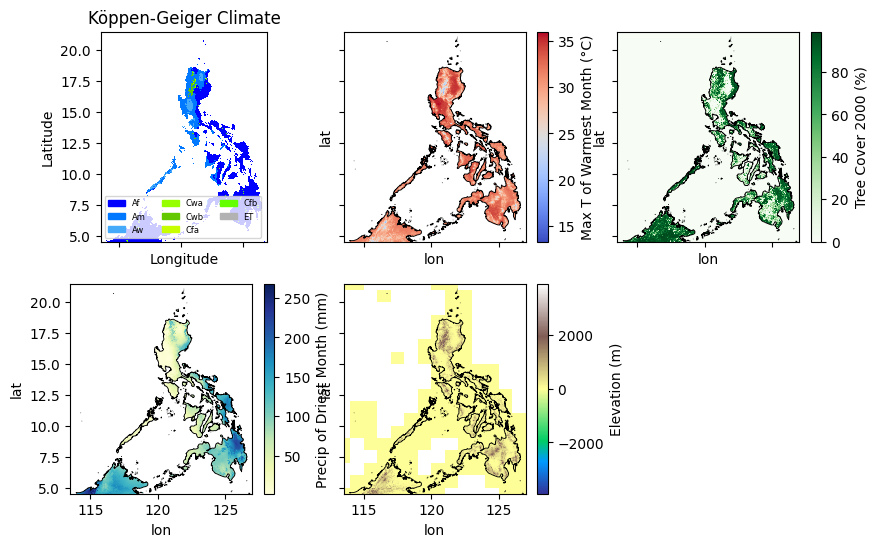

In [29]:
# 17
for ax in axes.ravel()[1:5]:     # ✏️ how do you index 1-5 again?
    add_lsm(ax)                 # ✏️ use your add_lsm

fig

> **Discussion:** which of these variables do you think is most important for tarsier presence? Are there any variables you think are not important?

As evident from the lower left corners of our plots, our data still includes a large chunk of Borneo. We're only interested in the Philippines, so using the same logic as in part I of today, **🖊️ cut the Borneo area out of our region of interest**.

**Hint:** we're not interested in whatever data at `lat`itudes `< 7.5` **AND** `lon`gitudes `< 119.3`.

**Step 1:** create a boolean mask for the Borneo corner:

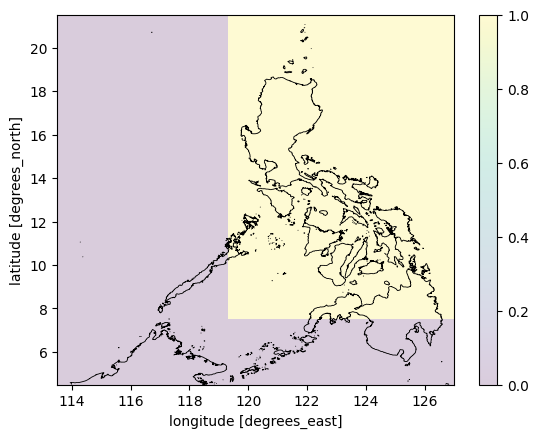

In [32]:
# 18
# ✏️ What two conditions should be met?
borneo_corner = (kg_grid['lat'] > 7.5) & (kg_grid['lon'] > 119.3)     # Hint: use kg_grid['lat'], kg_grid['lon'] and the '&' operator

fig, ax = plt.subplots()
borneo_corner.plot(ax=ax, alpha=0.2)

add_lsm(ax)  # ✏️ use your add_lsm to add the land-sea mask contour to the plot

Does that look good? You should be seeing the borneo mask and the land-sea mask plotted together. If you don't get any error but also don't see the land-sea mask, the `lat` and `lon` coordinates in `borneo_corner` are probably switched.

**Step 2:** starting from the standard land-sea mask (`land-sea-mask_0p00833333.nc`), now use your `borneo_corner` to make a new boolean that ONLY returns `True` (or `1`) over Philippine land:

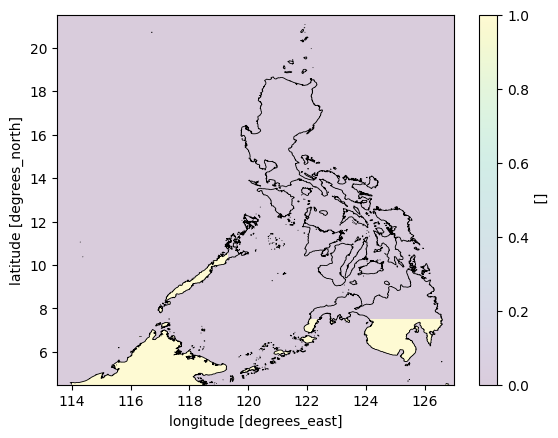

In [33]:
# 19
# ✏️ load land-sea-mask_0p00833333.nc, path: ../data/processed/
lsm = xr.open_dataset("../data/processed/land-sea-mask_0p00833333.nc")

# ✏️ Where is Philippine land only?
# Hint: where lsm["land_sea_mask"] > 0.5 AND NOT borneo_corner
ph_land = (lsm["land_sea_mask"] > 0.5) & (~borneo_corner)

fig, ax = plt.subplots()
ph_land.plot(ax=ax, alpha=0.2)

add_lsm(ax)     # ✏️ use your add_lsm to add the land-sea mask contour to the plot

Does that look correct? All Philippine land should be equal to 1, everything else zero.

As Myles would say: **cool beans!** We're now ready to set up our **'sampling campaign'**: points where we'll sample for tarsier presence and accompanying environmental data.

**On the one hand**, we have our tarsier **occurrence** data. It's not vast, but at least we have quite some locations where we can safely assume tarsier actually live. **On the other hand**, there's every single other point in the Philippines where we don't have a sighting available. **We'll randomly sample** a bunch of all possible locations. Most of these will not have a tarsier sighting, and so we'll have **'pseudo-abscences'**, as we can't actually tell for sure that the tarsier is absent there.

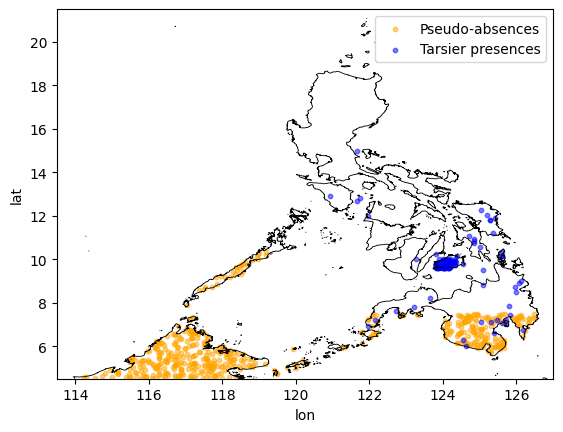

In [34]:
# 20
n_pseudo = 500                              # we want 500 pseudo-absence points
rng = np.random.default_rng(42)             # ignore this

roi_rows, roi_cols = np.where(ph_land)      # get the row and column indices of the Philippine land pixels

idx = rng.choice(len(roi_rows),             # randomly select land pixels
                 size=n_pseudo,
                 replace=False)

pseudo_df = pd.DataFrame({                  # put these in a DataFrame
    'lon': kg_grid['lon'].values[roi_cols[idx]],
    'lat': kg_grid['lat'].values[roi_rows[idx]],
})

# plot
fig, ax = plt.subplots()
pseudo_df.plot.scatter(x='lon', y='lat', ax=ax, alpha=0.5, s=10, color='orange', label='Pseudo-absences')
tarsier_clean.plot.scatter(x='lon', y='lat', ax=ax, alpha=0.5, s=10, color='blue', label='Tarsier presences')
add_lsm(ax)

**Voila!** Sampling strategy <span style="color: green">&#10004;</span> check.

Alright so we have:
- tarsier occurrence data
- a bunch of possible environmental predictors
- a sampling strategy

How do we now find out what environmental conditions are associated with our cute lil' bugger? There's **another obstacle:** `kg_grid`, `bio_ds`, `dem_ds` and `forest_ds` all share the same 1 km resolution grid, but what about `tarsier_clean`?

Sometimes Python is almost like speaking plain English. **🖊️ Check if longitudes and latitudes** in tarsier_clean (e.g. tarsier_clean['lon']) **match** the values in of the coordinates in kg_grid (e.g. kg_grid['lon'].values) by using the `.isin()` method:

In [42]:
kg_grid['lon']

<xarray.DataArray 'lon' (lon: 1620)> Size: 13kB
array([113.502993, 113.511326, 113.519659, ..., 126.977939, 126.986272,
       126.994605])
Coordinates:
  * lon      (lon) float64 13kB 113.5 113.5 113.5 113.5 ... 127.0 127.0 127.0
Attributes:
    units:      degrees_east
    long_name:  longitude

In [43]:
# 21
# ✏️ are tarsier_clean's lon/lat values also present in kg_grid's own lon/lat coordinates?

lon_match = tarsier_clean['lon'].isin(kg_grid['lon'].values) # Hint: use .isin(...) on tarsier_clean['lon'] to check if the values exist in kg_grid['lon'].values

lat_match = tarsier_clean['lat'].isin(kg_grid['lat'].values)  # Same for latitudes

print(f"lon values that exist in the grid: {lon_match.sum()}/{len(tarsier_clean)}")
print(f"lat values that exist in the grid: {lat_match.sum()}/{len(tarsier_clean)}")

lon values that exist in the grid: 0/262
lat values that exist in the grid: 0/262


**None** of `tarsier_clean`'s coordinates line up exactly with a `kg_grid` grid point. That makes sense: GPS coordinates from real sightings can fall anywhere, while our environmental grids only have values at fixed points spaced ~0.0083° (~1 km) apart. So `.isin()` (exact match) is the wrong tool here.

So if we want to associate a tarsier sighting with certain environmental conditions, **what we'll do instead is select the nearest by grid cell** for those environmental conditions.

**Below is** an **OPTIONAL** build-up towards doing that yourself if you're in the mood for a challenge. If not, you can go ahead and skip until the end of the challenge.

**💥 CHALLENGE 💥** Let's build that up step by step, starting from a tiny toy example.

**🖊️ Step 1:** for one query value on one small toy grid, find the closest grid value.

In [45]:
# 22
# a tiny toy coordinate grid, and one point we want to place on it
toy_longitudes = np.array([120.0, 120.5, 121.0, 121.5, 122.0])
toy_lon = 121.3

# ✏️ use np.abs(...) on the difference between toy_longitudes and toy_lon
# This returns the distance from toy_lon to every grid value
distances = np.abs(toy_longitudes - toy_lon)    # np.abs() just returns the absolute value
print("distances:", distances)

# ✏️ Hint: distances.argmin() returns the index of the smallest value
nearest_idx = distances.argmin()
print(f"{toy_lon} is closest to grid value {toy_longitudes[nearest_idx]} (index {nearest_idx})")

distances: [1.3 0.8 0.3 0.2 0.7]
121.3 is closest to grid value 121.5 (index 3)


That handles one point at a time. But we have hundreds of tarsier points (and 500 pseudo-absences) — looping over each one individually in Python would work, but it's slow and clunky. Why be slow if you can be fast?

**💥 CHALLENGE 💥**

**🖊️ Step 2:** vectorize it. NumPy broadcasting lets us compute the distance from *every* query point to *every* grid value in one shot: `toy_queries[:, None]` (shape `(n_queries, 1)`) minus `toy_grid[None, :]` (shape `(1, n_grid)`) broadcasts into a full `(n_queries, n_grid)` table of distances.

In [50]:
# 23
toy_lons = np.array([120.1, 121.49, 121.51, 122.9]) # we're now looking at multiple lons at the same time

# ✏️ toy_queries[:, None] is (4, 1), toy_grid[None, :] is (1, 5)
# -> their difference broadcasts to a (4, 5) distance table
# -> use np.abs(...) on their difference
distances = np.abs(toy_lons[:, None] - toy_longitudes[None, :])
print("distances shape:", distances.shape)

# ✏️ nearest grid index for every query at once -- argmin along the grid axis (axis=1)
nearest_idx = distances.argmin(axis=1)

for q, i in zip(toy_lons, nearest_idx):
    print(f"{q} -> grid value {toy_longitudes[i]} (index {i})")

distances shape: (4, 5)
120.1 -> grid value 120.0 (index 0)
121.49 -> grid value 121.5 (index 3)
121.51 -> grid value 121.5 (index 3)
122.9 -> grid value 122.0 (index 4)


Same trick, full scale. `kg_grid`, `bio_ds`, `dem_ds`, and `forest_ds` all share the exact same 1 km lon/lat grid, so we only need to do this lookup once — separately for longitude and for latitude, since the grid is regular (a rectilinear grid: any `(row, col)` pair is just one `lon` value crossed with one `lat` value) — to turn any `(lon, lat)` point into a `(row, col)` index.

**💥 CHALLENGE 💥**

**🖊️ Step 3:** reuse your broadcasting trick from above, once per axis:

In [57]:
# 24
PH_LON = kg_grid['lon'].values
PH_LAT = kg_grid['lat'].values


def nearest_rowcol(lons, lats, grid_lon=PH_LON, grid_lat=PH_LAT):
    """Nearest-grid-cell (row, col) index for every (lon, lat) point, vectorised over the whole grid at once."""

    # ✏️ same broadcasting trick as above -- once for longitude (-> column index)
    col_idx = np.abs(np.asarray(lons)[:, None] - grid_lon[None, :]).argmin(axis=1)

    # ✏️ ... and once for latitude (-> row index)
    row_idx = np.abs(np.asarray(lats)[:, None] - grid_lat[None, :]).argmin(axis=1)

    return row_idx, col_idx


# quick sanity check on the first few real tarsier points
row_idx, col_idx = nearest_rowcol(tarsier_clean['lon'].values[:3], tarsier_clean['lat'].values[:3])
for (lon, lat), r, c in zip(tarsier_clean[['lon', 'lat']].values[:3], row_idx, col_idx):
    print(f"({lon}, {lat}) -> nearest grid cell ({PH_LAT[r]:.4f}, {PH_LON[c]:.4f})")

(125.617, 10.35) -> nearest grid cell (10.3462, 125.6196)
(125.0798, 9.525) -> nearest grid cell (9.5212, 125.0779)
(125.2777, 11.8131) -> nearest grid cell (11.8128, 125.2779)


**⚠️ END OF THE CHALLENGE ⚠️**

...

Here's the solution to the challenge, **make sure you run the cell** so you can use the function below:

In [58]:
# 25
PH_LON = kg_grid['lon'].values
PH_LAT = kg_grid['lat'].values


def nearest_rowcol(lons, lats, grid_lon=PH_LON, grid_lat=PH_LAT):
    """Nearest-grid-cell (row, col) index for every (lon, lat) point, vectorised over the whole grid at once."""
    col_idx = np.abs(np.asarray(lons)[:, None] - grid_lon[None, :]).argmin(axis=1)
    row_idx = np.abs(np.asarray(lats)[:, None] - grid_lat[None, :]).argmin(axis=1)
    return row_idx, col_idx

In case you didn't do the challenge, here's **a small explanation of** what our new function `nearest_rowcol` does:

It **takes in longitude and latitude** values, **and returns** what the **nearest** row (latitude) and column (longitude) **grid point** in our 1-km shared grid is (the grid of kg_grid, dem_ds, etc.: our environmental data). That way, we can easily look up what the evironmental conditions are associated with a given tarsier sighting or absence.

**One more thing to check before we build the final dataset.** We're about to snap *every* point — all 277 real tarsier sightings and all 500 random pseudo-absences — onto this same 1 km grid. **What if** a pseudo-absence happens to land in the *exact same grid cell* as a real sighting?.

**🖊️ Your turn:** Let's drop any pseudo-absences that collide with a real presence's grid cell:

In [ ]:
# 26
# ✏️ Use nearest_rowcol to compute the closest grid points associated with both tarsier_clean and pseudo_df

# 1) THE TARSIER SIGHTINGS
pres_row, pres_col = nearest_rowcol(
    ...,  # Hint: pass the lon values of tarsier_clean
    ...   # Hint: same for lat values
)

# 2) THE PSEUDO-ABSENCES
pseudo_row, pseudo_col = nearest_rowcol(
    ...,  # Same as above but for pseudo_df
    ...
)

# a set of (row, col) tuples makes "is this pixel a presence?" a fast lookup
presence_cells = set(zip(pres_row, pres_col))
is_contaminated = np.array([(r, c) in presence_cells for r, c in zip(pseudo_row, pseudo_col)])

print(f"{is_contaminated.sum()} of {len(pseudo_df)} pseudo-absences land on the same grid cell as a real tarsier sighting")

# drop those before we use pseudo_df any further
pseudo_clean = pseudo_df[~is_contaminated].reset_index(drop=True)

Nice! Maybe at this point you still find it a little abstract, so **let's visualize what you have just done**.

Here's a plot that focuses on the clustered Bohol **observations on the left**, and **on the right** it shows the corresponding **nearest pixels** to those observations:

In [ ]:
# 27
# --- Define your zoom window ---
lon_min, lon_max = 123.4, 124.6
lat_min, lat_max = 9.5, 10.1   # note: min < max

# --- Helper: find nearest grid index for a coordinate ---
def nearest_idx(arr, val):
    return int(np.argmin(np.abs(np.asarray(arr) - val)))

# Column indices (longitude)
col_min = nearest_idx(PH_LON, lon_min)
col_max = nearest_idx(PH_LON, lon_max)
col_min, col_max = sorted([col_min, col_max])

# Row indices (latitude) — handle either ascending or descending PH_LAT
row_a = nearest_idx(PH_LAT, lat_min)
row_b = nearest_idx(PH_LAT, lat_max)
row_min, row_max = sorted([row_a, row_b])

# 1. Blank raster
grid_shape = (len(PH_LAT), len(PH_LON))
presence_raster = np.zeros(grid_shape)
presence_raster[pres_row, pres_col] = 1

# 2. Plot side-by-side, both cropped to the same region
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Recorded Sighting Locations
ax1.scatter(tarsier_clean['lon'], tarsier_clean['lat'],
            color='crimson', s=15, alpha=0.7)
ax1.set_title("Tarsier Sighting Locations (Coordinates)")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.set_xlim(lon_min, lon_max)
ax1.set_ylim(lat_min, lat_max)
ax1.set_aspect("equal")

# Right: Pixelized Presence Raster, zoomed to matching pixel range
im = ax2.imshow(presence_raster, cmap="YlOrRd", origin="upper")
ax2.set_title("Presence Pixels on Grid (Raster)")
ax2.set_xlabel("Column Index")
ax2.set_ylabel("Row Index")
ax2.set_xlim(col_min, col_max)

# For imshow with origin='upper', row 0 is at the top, so to zoom in with
# matching lat orientation we need row limits flipped correctly:
if PH_LAT[0] > PH_LAT[-1]:   # lat decreasing with row index (row 0 = north)
    ax2.set_ylim(row_max, row_min)   # imshow y-axis is inverted already
else:                        # lat increasing with row index
    ax2.set_ylim(row_min, row_max)

plt.suptitle("Zoom into Bohol cluster", y=0.82, fontsize=16)
plt.tight_layout()
plt.show()

> 💬 **Discussion:** Only one collision out of 500 — small, but not zero. Worth checking regardless: we don't want data that says that tarsiers both live and don't live at the same location.

**Sampling strategy, properly checked ✓.** We now have a clean way to snap any `(lon, lat)` point onto our shared 1 km grid, and a `tarsier_clean` / `pseudo_clean` pair with no grid-cell collisions between them. **Time to put it all together:** for every presence and pseudo-absence coordinate, look up its nearest grid cell and pull out the matching Köppen-Geiger class, BIO5, BIO14, elevation, and tree cover.

Below, we make a function `extract_predictors` that does just this.
- Its `input`: a DataFrame such as `tarsier_clean` or `pseudo_clean`.
- It uses our function `nearest_rowcol` to extract the nearest grid row and column indices for all observations
- It `return`s the environmental variables at those row and column indices

In [ ]:
# 28
def extract_predictors(df):

    # STEP 1: Find the nearest grid cell for each point in df
    row_idx, col_idx = nearest_rowcol(
        ...,  # ✏️ same as above but for df
        ...
    )
    out = df.copy()

    # STEP 2: Extract the environmental values from each dataset at those grid cells:

    # a) Köppen-Geiger climate class
    out['kg_class']      = kg_grid['kg_class'].values[row_idx, col_idx]

    # b) BIO5: Max Temperature of Warmest Month
    out['bio5']          = ... # ✏️ data is in bio_ds

    # c) BIO14: Precipitation of Driest Month
    out['bio14']         = ... # ✏️ data is in bio_ds

    # d) Elevation
    out['elevation']     = ... # ✏️ data is in dem_ds

    # e) Tree cover in 2000
    out['treecover2000'] = ... # ✏️ data is in forest_ds

    return out


print('Extracting values at presence points ...')
tarsier_out = extract_predictors(tarsier_clean)
tarsier_out['presence'] = 1

print('Extracting values at pseudo-absence points ...')
pseudo_out = extract_predictors(pseudo_clean)
pseudo_out['presence'] = 0

sdm_df = pd.concat([tarsier_out, pseudo_out], ignore_index=True).dropna()
n_pres = int(sdm_df['presence'].sum())
n_abs  = int((sdm_df['presence'] == 0).sum())
print(f'\nSDM dataset: {n_pres} presences + {n_abs} background points')
sdm_df.head()

> **Discussion:** Can you describe what we did to get here? What did we just create?

Now that we have this structured DataFrame, let's see if we can do some cool things with it!

## *PART III: Species distribution modeling*

*Recap: thousands of hectares of land on Minanao will be sold to a large industrial agricultural stakeholder, unless we can show the government that this region is key to sustainable conservation of the Philippine tarsier population.*

Remember how in Day 1 we did climate data -> decision tree -> climate classification? And in Day 2, we did satellite imagery -> NDVI -> decision tree -> land cover classification? We've already used simple **"rule" functions** in a descriptive setting. **Let's use the same logic in a predictive setting!**

For a given location (`lat`, `lon`), we can **split** our `sdm_df` into **predictors** (`kg_class`, `bio5`, `bio14`, `elevation`, `treecover2000`: the variables we use to make a prediction) **and target** (`presence`: the variable we want to predict).

This time, there's no "rule" for us to implement: we don't know what the optimal environmental conditions for the Philippine tarsier are yet. **Instead, what we do is let a model *learn* those optimal conditions from the data.** This is called **machine learning**.

There's a million different models available out there which could learn the relationships in our data. Here, we'll use the simple `LogisticRegression` from the `sklearn` (*Scikit learn*) library. The details are not relevant right now, but if you're interested in how the model works nonetheless you can read its [< documentation >](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).

### Fit the model

When somebody says **machine learning** it sounds really fancy, but here you'll see just how easy it is to fit a model with Python. The modeling part is easy, but understanding what data you need for the situation, where to get that data, how to process that data, how all different models work, when to use what model and how to use it wisely and resposively, those are the hard parts.

Fitting an `sklearn` model is as easy as **1)** defining it and **2)** just running `.fit`(use these variables to predict, predict this variable):

In [ ]:
# 29
FEATURES = [..., ..., ..., ..., ...]  # ✏️ what column names in sdm_df should we use as predictors for the SDM?

X = sdm_df[FEATURES].values
y = sdm_df[...].values  # ✏️ What is the column name in sdm_df for tarsier presence/absence?

model = LogisticRegression(max_iter=1000)
...  # ✏️ fit the model using .fit(X, y)

probs = model.predict_proba(X)[:, 1]
print('Coefficients:')
for name, coef in zip(FEATURES, model.coef_[0]):
    print(f'  {name:>13s}: {coef:+.4f}')
print(f'  {"intercept":>13s}: {model.intercept_[0]:+.4f}')
print(f'\nAUC: {roc_auc_score(y, probs):.3f}  (0.5 = no better than random, 1.0 = perfect separation)')

> **Discussion:** look at the coefficients. If a variable's coefficient is negative, the model has learned a negative relationship between that variable and tarsier presence, and positive vice versa. What relationships has our model learned?

### Predict suitability across the Philippines

Apply the fitted model to every land pixel of the shared 1 km grid — excluding the bbox's Borneo
corner, same as the background sampling in Part II — to get a Philippines-wide habitat suitability
map at real 1 km resolution.

In [ ]:
# 30
rows, cols = np.where(ph_land)
X_grid = np.column_stack([
    kg_grid['kg_class'].values[rows, cols],
    bio_ds['bio5'].values[rows, cols],
    bio_ds['bio14'].values[rows, cols],
    dem_ds['elevation'].values[rows, cols],
    forest_ds['treecover2000'].values[rows, cols],
])
valid = ~np.isnan(X_grid).any(axis=1)   # a few coastal cells fall on WorldClim/KG nodata -- see Part IV

suitability = np.full(ph_land.shape, np.nan, dtype='float32')
suitability[rows[valid], cols[valid]] = model.predict_proba(X_grid[valid])[:, 1]

print(f'Predicted {valid.sum():,} land cells ({(~valid).sum()} skipped, no predictor data)')
print(f'Suitability range: {np.nanmin(suitability):.3f} to {np.nanmax(suitability):.3f}')

### Plot the suitability map

Overlay the real (cleaned) presence points — does the high-suitability zone concentrate around the
tarsier's documented native range (the Mindanao faunal region: Mindanao, Bohol, Leyte, Samar)? That's
the sanity check `example_study.pdf`'s congener trick would normally provide, adapted here since the
tarsier has no close congener in the Philippines to compare against.

In [ ]:
# 31
fig, ax = plt.subplots(figsize=(7, 9))
im = ax.pcolormesh(PH_LON, PH_LAT, suitability, cmap='viridis', shading='auto')
plt.colorbar(im, ax=ax, label='Predicted suitability', shrink=0.7)

presence_pts = sdm_df[sdm_df['presence'] == 1]
ax.scatter(presence_pts['lon'], presence_pts['lat'], s=8, color='red', label='Tarsier presence')

ax.set_xlim(PH_LON.min(), PH_LON.max())
ax.set_ylim(PH_LAT.min(), PH_LAT.max())
ax.set_aspect('equal')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Predicted habitat suitability — Philippine tarsier (present-day)')
ax.legend(loc='lower left', frameon=False)

## Well done — Day 3 complete!

For the people that like a **💥 CHALLENGE 💥**: scroll to the bottom of the notebook.

### Recap: what did we actually do today?

- **Part I** — turned raw GBIF sightings into a clean presence dataset: filtered out clearly out-of-range points, deduplicated near-identical coordinates, and discussed why *presence-only* data (no confirmed absences) is the norm in ecology, not the exception.
- **Part II** — turned "the tarsier needs cool, humid, forested land" into numbers: pulled Köppen-Geiger class, BIO5, BIO14, elevation, and tree cover at every sighting, generated random pseudo-absences across the Philippines, and snapped everything onto one shared 1 km grid.
- **Part III** — fit a `LogisticRegression` to learn presence/absence from those five predictors, read off its coefficients, and projected it across the whole Philippines to get a suitability map — then checked whether that map actually matches the tarsier's documented range.

You went from scattered dots on a map to a quantitative, reproducible, Philippines-wide prediction. That's genuinely the core workflow behind real species distribution modeling (SDM) papers.

### But — main limitations of what we just did

> **Discussion:** before reading on, look back at the suitability map from Part III. Does it convince you that Mindanao specifically matters for the tarsier? Why or why not?

A few things should make us cautious about over-trusting that map:

1. **`kg_class` is categorical, but we fed it to the model as if it were a number.** Köppen-Geiger codes (1, 2, 3, …) have no inherent order or distance — class 3 isn't "worth 50% more" than class 2 the way BIO5 = 33°C is hotter than BIO5 = 22°C. `LogisticRegression` doesn't know that; it just sees a number and learns a slope for it, as if the classes formed a line.
2. **Sampling bias, not just ecology, shapes where points land.** The huge Bohol cluster reflects where researchers/tourists/institutions happen to visit, at least as much as it reflects tarsier ecology — and Mindanao being comparatively under-represented may be about access and survey effort (parts of it are simply harder/more dangerous to survey), not about tarsiers being absent there. A model trained on these points will inevitably lean toward "Bohol-like" conditions as "suitable," whether or not that's the whole ecological truth.
3. **We evaluated the model on the same data it was trained on.** The AUC we printed in Part III was computed on the training set itself — the model has already "seen the answers." That number tells us how well the model fits what we gave it, not how well it would predict a location it never saw.
4. **A linear model assumes linear relationships.** Logistic regression can only learn "more of X is monotonically better/worse for the tarsier." Real habitat suitability is often non-linear (e.g. a temperature *sweet spot*, not "colder is always better") — something a straight-line-in-log-odds model structurally cannot represent.

### What you did is exactly how a lot of research is done

And generally follows the core structure of many data science projects. This is not only relevant for research, but for a very very wide range of applications. **Good job!**

I hope you learned a lot.

---

### 💥 CHALLENGE (for the motivated) 💥

Let's see if we can address some of the theoretical and practical shortcomings of the SDM (species distribution model) above. There's a separate notebook for this: `hardcore.ipynb`.

Open it with:
  ```
   https://colab.research.google.com/github/Cas-Dec/USLS-Workshop/blob/main/notebooks/hardcore.ipynb
  ```